In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

### 1) ช่วงวัย ที่มี การ Order มากที่สุด ในปี 2023

In [ ]:
order_per_ageGroup = (
    df[df["Year"] == 2023]
    .groupby("AgeGroup")["Customer ID"]
    .nunique()
    .sort_values(ascending=False)
)

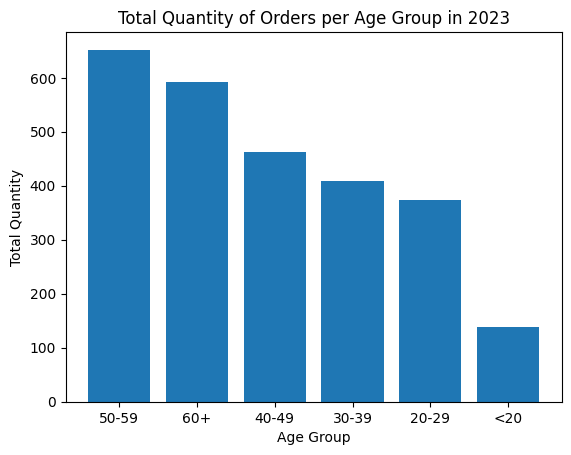

In [5]:
plt.bar(order_per_ageGroup.index, order_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Total Quantity")
plt.title("Total Quantity of Orders per Age Group in 2023")
plt.show()

### 2) ช่วงวัย ที่มี การ Delivery(เก็บเงิน) มากที่สุด ในปี 2023

In [ ]:
delivered_per_ageGroup = (
    df[(df["Year"] == 2023) & (df["Delivered"] == True)]
    .groupby("AgeGroup")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

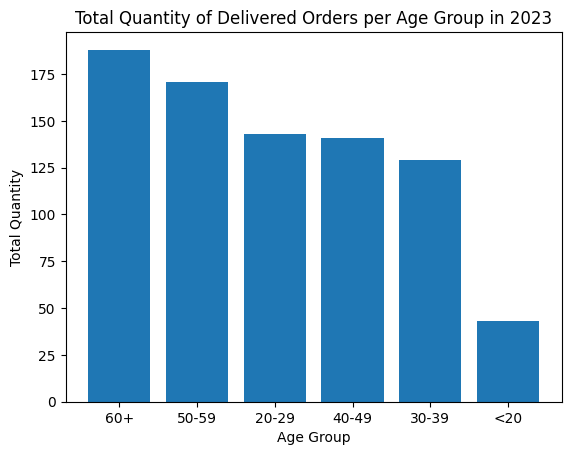

In [11]:
plt.bar(delivered_per_ageGroup.index, delivered_per_ageGroup.values)
plt.xlabel("Age Group")
plt.ylabel("Total Quantity")
plt.title("Total Quantity of Del per Age Group in 2023")
plt.show()

### Conversion Rate ต่อช่วงวัย ปี2023

In [15]:
conversion_rate = (
    delivered_per_ageGroup / order_per_ageGroup
) * 100

In [16]:
print(conversion_rate)

AgeGroup
20-29    38.337802
30-39    31.617647
40-49    30.519481
50-59    26.226994
60+      31.703204
<20      31.159420
Name: Quantity, dtype: float64


##### จากการวิเคราะห์ เบื้องต้น กลุ่ม ช่วงสูงอายุ ตั้งแต่ 50-60 มีจํานวนการ Order และ บริษัท เก็บเงินได้ดีที่สุด แต่ อัตรา การชําระเงิน conversion rate แสดงไห้ เห็นว่ากลุ่มดังกลบ่าว ไม่ได้มีอัตรา การซื้อ ที่มากที่สุด และ ยังไม่สามารถสรุป ได้ว่ากลุ่ม สูงวัย 50-60 เป็นช่วงวัย กลุ่มทือง ของ บริษัท Eccomerce เรา ต้องวิเคราะห์ลึกขึ้นอีก ด้านล่าง

##### วิเคราะห์ต่อยอด จากด้านบน

#### จำนวนลูกค้าในแต่ละกลุ่ม

In [17]:
df[df["Year"] == 2023].groupby("AgeGroup")["Customer ID"].nunique().sort_values(ascending=False)

AgeGroup
50-59    65
60+      60
40-49    51
20-29    47
30-39    45
<20      17
Name: Customer ID, dtype: int64

In [22]:
df[(df["Year"] == 2023) & (df["Delivered"] == True)] \
.groupby("AgeGroup")["Quantity"].mean().sort_values(ascending=False)

AgeGroup
<20      3.307692
20-29    3.250000
50-59    2.948276
60+      2.937500
30-39    2.866667
40-49    2.764706
Name: Quantity, dtype: float64

In [25]:
df[(df["Year"] == 2023) & (df["Delivered"] == True)] \
.groupby("AgeGroup")["Quantity"].sum().sort_values(ascending=False)

AgeGroup
60+      188
50-59    171
20-29    143
40-49    141
30-39    129
<20       43
Name: Quantity, dtype: int64

##### จะเห็นได้ว่า สาเหตุ จากหัวข้อด้านบน เราสรุปได้ว่า กลุ่มลูกค้าวัย 50-60 เป็นกลุ่มลูกค้าที่มีจํานวนมากจริง แต่ อัตราการซื้อ ไม่ได้สูงที่สุด แต่สาเหตุเพราะ ขนาด Data Size ,ีความแตกต่างมาก 

##### แต่ขณะเดียวกัน กลุ่ม ช่วงวัย อายุ น้อยกว่า 20 มีอัตราการสั่งซื้อ สูงที่สุด แต่เนื่องจาก ขาดกลุ่มลูกค้า มีน้อยกว่า กลุ่มลูกค้าสูงวัย ค่าจึงตํ่า

##### กลุ่มลูกค้าทอง จริงของ บริษัท Eccomerce เราคือ ช่วง อายุน้อยกว่า20 ถ้าเราสามารถเข้าถึง และ เพิ่มกลุ่มลูกค้านี้ได้เเพิ่มขึ้น โอการรายได้จะ เข้า มีเยอะกว่าเดิมแน่นอน
